Importing Libraries

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

Load the Dataset

In [54]:
# load the CSV
df = pd.read_csv("../data/Housing.csv")

# first look
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [55]:
df.shape


df.info()


df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [56]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [57]:
df['basement'].value_counts()

basement
no     354
yes    191
Name: count, dtype: int64

In [58]:
binary_cols = [col for col in df.columns if df[col].nunique(dropna=True) == 2]

print(binary_cols)

['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']


In [59]:
binary_cols = ["mainroad","guestroom","basement",
               "hotwaterheating","airconditioning","prefarea"]

for col in binary_cols:
    df[col] = df[col].map({"yes":1, "no":0})

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


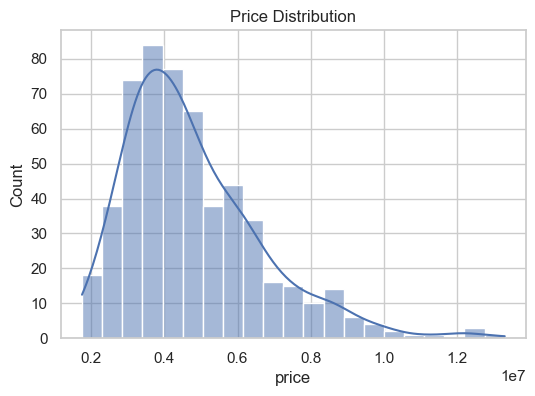

In [60]:
plt.figure(figsize=(6,4))
sns.histplot(df["price"], kde=True)
plt.title("Price Distribution")
plt.show()

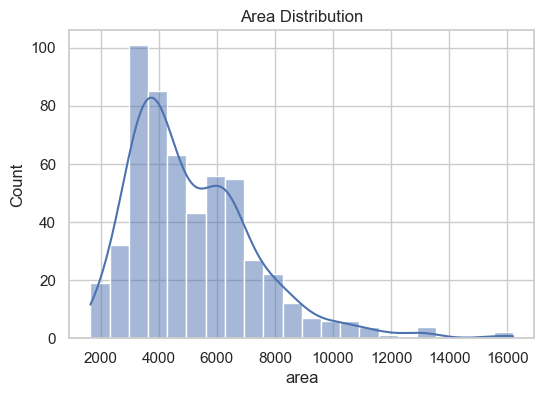

In [61]:
plt.figure(figsize=(6,4))
sns.histplot(df["area"], kde=True)
plt.title("Area Distribution")
plt.show()

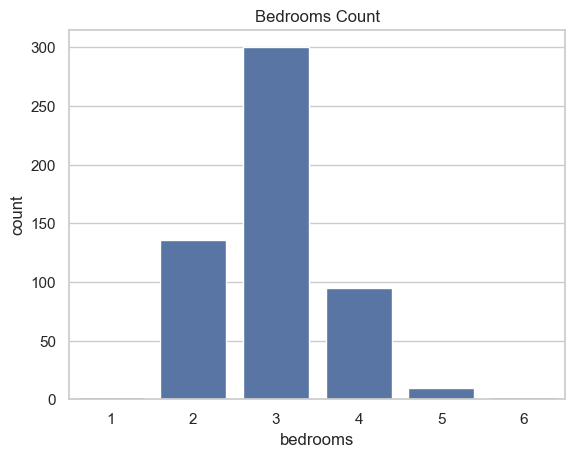

In [62]:
sns.countplot(x="bedrooms", data=df)
plt.title("Bedrooms Count")
plt.show()

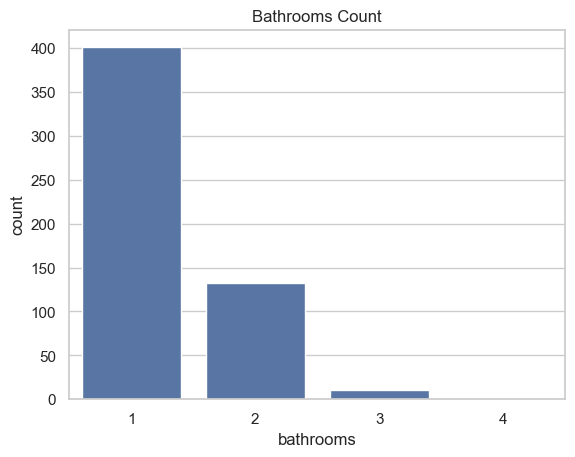

In [63]:
sns.countplot(x="bathrooms", data=df)
plt.title("Bathrooms Count")
plt.show()

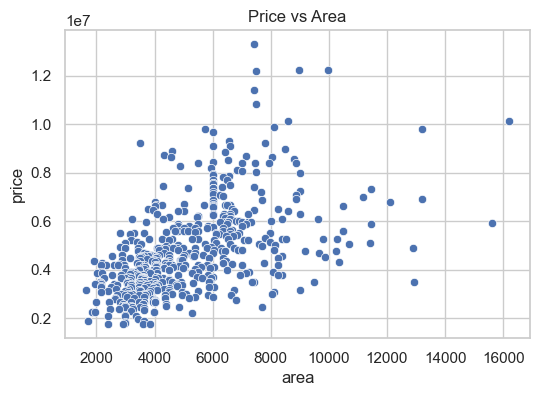

In [64]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="area", y="price", data=df)
plt.title("Price vs Area")
plt.show()

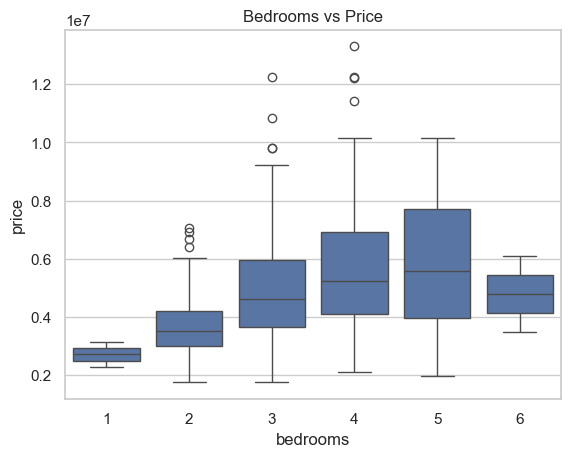

In [65]:
sns.boxplot(x="bedrooms", y="price", data=df)
plt.title("Bedrooms vs Price")
plt.show()

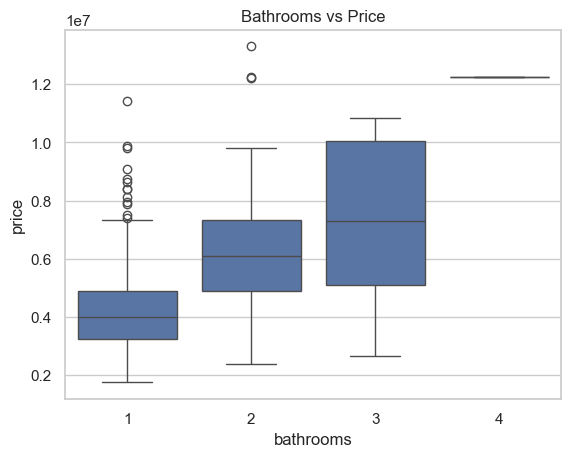

In [66]:
sns.boxplot(x="bathrooms", y="price", data=df)
plt.title("Bathrooms vs Price")
plt.show()

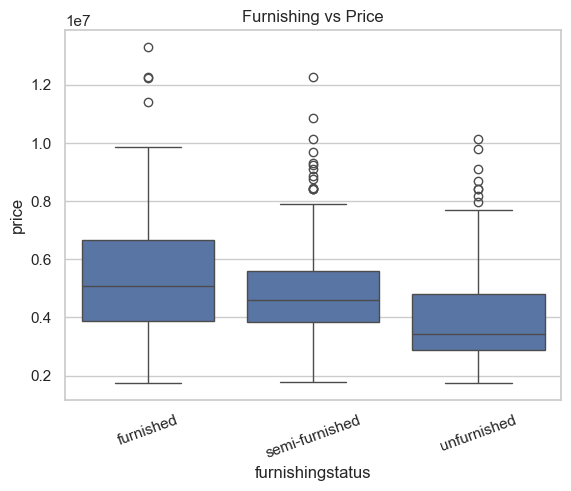

In [67]:
sns.boxplot(x="furnishingstatus", y="price", data=df)
plt.title("Furnishing vs Price")
plt.xticks(rotation=20)
plt.show()

In [68]:
df_encoded = pd.get_dummies(df, columns=["furnishingstatus"])

In [70]:
df_encoded.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False


In [71]:
df = df_encoded

In [72]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,True,False,False
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,True,False,False
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,False,True,False
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,True,False,False
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,True,False,False


In [75]:
df['furnishingstatus_furnished'] = df['furnishingstatus_furnished'].astype(int)
df['furnishingstatus_unfurnished'] = df['furnishingstatus_unfurnished'].astype(int)
df['furnishingstatus_semi-furnished'] = df['furnishingstatus_semi-furnished'].astype(int)

In [76]:
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus_furnished,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1,0,0


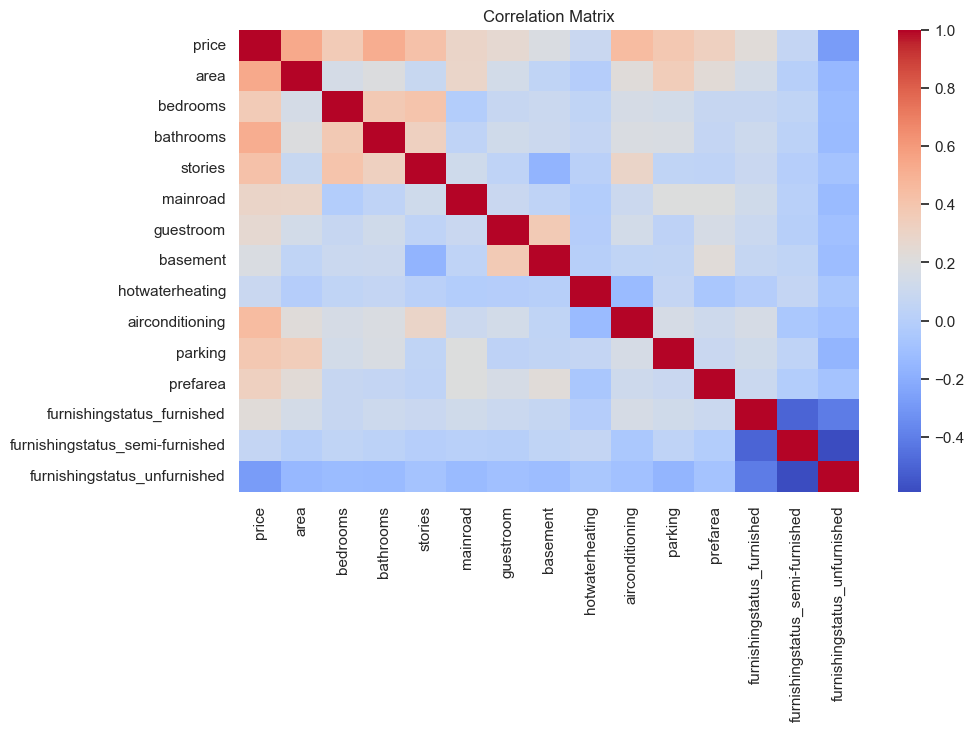

In [79]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

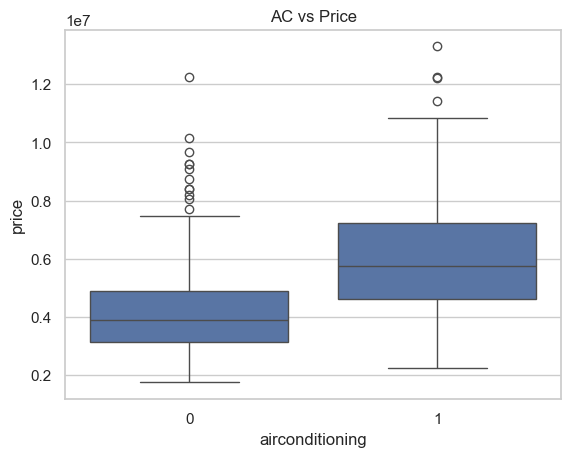

In [81]:
sns.boxplot(x="airconditioning", y="price", data=df)
plt.title("AC vs Price")
plt.show()

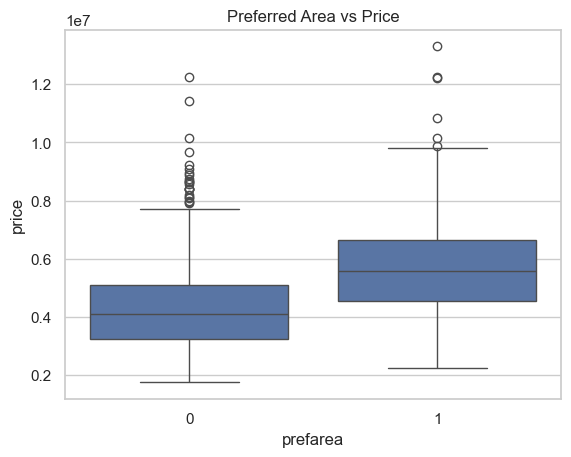

In [82]:
sns.boxplot(x="prefarea", y="price", data=df)
plt.title("Preferred Area vs Price")
plt.show()

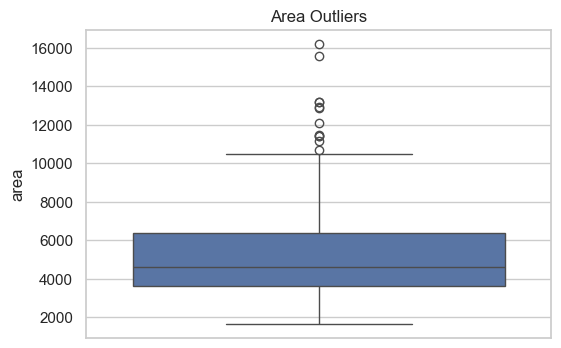

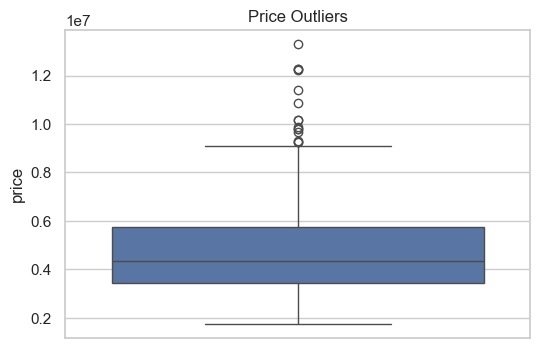

In [83]:
plt.figure(figsize=(6,4))
sns.boxplot(y="area", data=df)
plt.title("Area Outliers")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(y="price", data=df)
plt.title("Price Outliers")
plt.show()